# 02 — Radial Distribution (Free Vortex)

**Purpose:** Extend the meanline result spanwise using the free-vortex law (r·Cθ = const). Verify that De Haller and Lieblein DF stay within limits at every radial station from hub to tip. Confirm hub loading is not excessive.

**Inputs:** Design point from `01_meanline_sweep.ipynb`.

**Outputs:**
- Spanwise distributions of β₁, β₂, α₂, Δβ, W₂/W₁, DF
- Flag of any station where DF > 0.45
- Confirmation that the free-vortex law is a valid approximation

**References:** Dixon & Hall (2014) Ch. 6; Lieblein et al. (1953) NACA RM E53D01.

In [12]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import numpy as np
import matplotlib.pyplot as plt

from src.meanline import meanline_analysis
from src.radial   import free_vortex
from src.plotting import plot_radial

plt.rcParams.update({'figure.dpi': 130, 'font.size': 10})
print('Imports OK')

Imports OK


## 1. Design point (from notebook 01)

In [13]:
D_tip = 0.900  # m
N     = 3500   # RPM
PR    = 1.10
eta   = 0.85
nu    = 0.75
phi   = 0.725

res = meanline_analysis(D_tip, N, PR, eta, nu=nu, phi=phi)
print(f'Mean radius  : {res["r_mean"]*1000:.1f} mm')
print(f'Blade height : {res["h_mm"]:.1f} mm')
print(f'ψ = {res["psi"]:.4f}   DH = {res["De_Haller"]:.4f}   P = {res["P_shaft_kW"]:.1f} kW')

Mean radius  : 393.8 mm
Blade height : 112.5 mm
ψ = 0.4514   DH = 0.7361   P = 335.4 kW


## 2. Free-vortex radial distribution

In [14]:
# Rotor mid-span solidity (auto-sized in igv.py; replicate here)
import math
r_mean = res['r_mean']
h      = res['r_tip'] - res['r_hub']
AR     = 1.5
B      = int(math.ceil(2 * math.pi * r_mean * 1.1 * AR / h))
if B % 2 == 0: B += 1
chord_mid = h / AR
pitch_mid = 2 * math.pi * r_mean / B
sigma_mid = chord_mid / pitch_mid

print(f'B = {B} blades,  chord_mid = {chord_mid*1000:.1f} mm,  σ_mid = {sigma_mid:.3f}')

rad = free_vortex(res, n_stations=80, sigma=sigma_mid)

B = 37 blades,  chord_mid = 75.0 mm,  σ_mid = 1.122


## 3. Three-panel radial plot

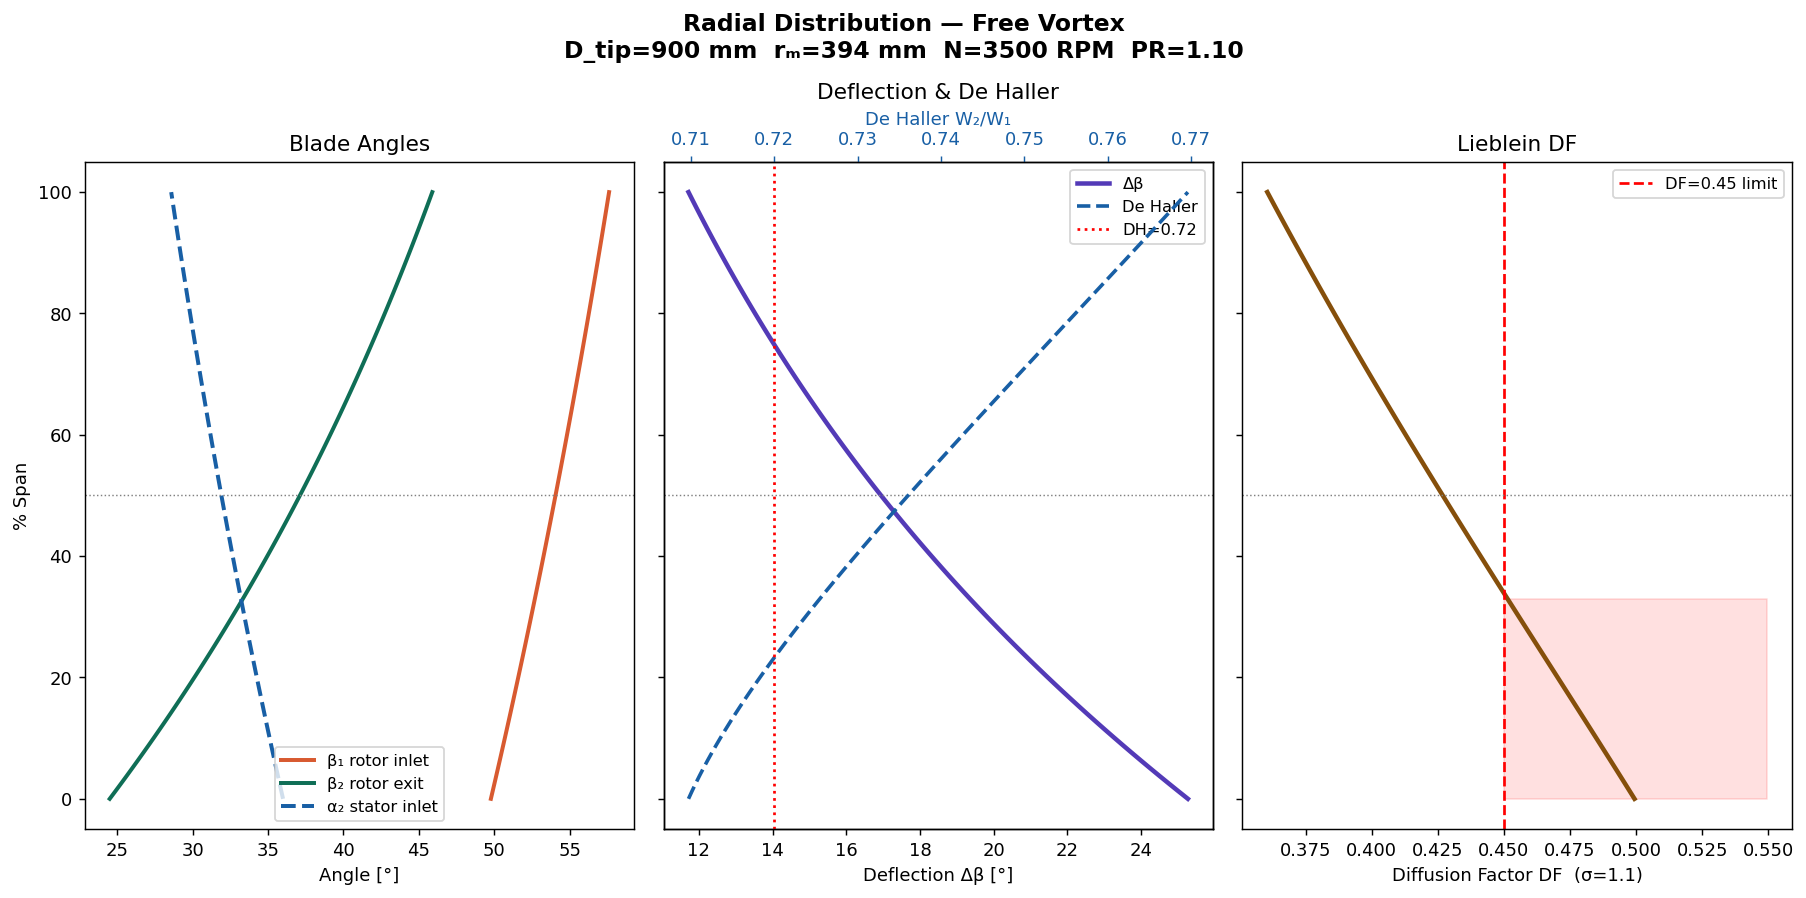

In [15]:
import pathlib
_r = next(p for p in [pathlib.Path.cwd()] + list(pathlib.Path.cwd().parents) if (p / "src").is_dir())
plot_radial(res, rad, save_path=str(_r / "figures" / "02_radial_distribution.png"))

## 4. Tabulate blade angles at key stations

In [16]:
import pandas as pd

# Sample at hub (0%), 25%, 50% (mean), 75%, tip (100%)
idx = [0, 20, 40, 60, 79]
tbl = pd.DataFrame({
    '% span'  : rad['pct_span'][idx].round(1),
    'r [mm]'  : (rad['r'][idx] * 1000).round(1),
    'U [m/s]' : rad['U_r'][idx].round(2),
    'β₁ [°]'  : rad['beta1'][idx].round(2),
    'β₂ [°]'  : rad['beta2'][idx].round(2),
    'Δβ [°]'  : rad['delta_beta'][idx].round(2),
    'α₂ [°]'  : rad['alpha2'][idx].round(2),
    'W₂/W₁'   : rad['DH'][idx].round(4),
    'DF'       : rad['DF'][idx].round(4),
})
print(tbl.to_string(index=False))

 % span  r [mm]  U [m/s]  β₁ [°]  β₂ [°]  Δβ [°]  α₂ [°]  W₂/W₁     DF
    0.0   337.5   123.70   49.77   24.50   25.27   36.00 0.7097 0.4994
   25.3   366.0   134.14   52.05   31.47   20.57   33.82 0.7211 0.4625
   50.6   394.5   144.58   54.11   37.24   16.86   31.86 0.7365 0.4260
   75.9   422.9   155.02   55.98   42.05   13.94   30.10 0.7534 0.3912
  100.0   450.0   164.93   57.61   45.89   11.72   28.58 0.7696 0.3605


## 5. Constraint check — flagged stations

In [17]:
dh_fail  = rad['pct_span'][rad['DH'] < 0.72]
df_fail  = rad['pct_span'][rad['DF'] > 0.45]

print('De Haller < 0.72 at % span:', dh_fail.round(1) if len(dh_fail) else 'None ✓')
print('Lieblein DF > 0.45 at % span:', df_fail.round(1) if len(df_fail) else 'None ✓')

print(f'\nDH range : {rad["DH"].min():.4f} – {rad["DH"].max():.4f}')
print(f'DF range : {rad["DF"].min():.4f} – {rad["DF"].max():.4f}')

De Haller < 0.72 at % span: [ 0.   1.3  2.5  3.8  5.1  6.3  7.6  8.9 10.1 11.4 12.7 13.9 15.2 16.5
 17.7 19.  20.3 21.5 22.8]
Lieblein DF > 0.45 at % span: [ 0.   1.3  2.5  3.8  5.1  6.3  7.6  8.9 10.1 11.4 12.7 13.9 15.2 16.5
 17.7 19.  20.3 21.5 22.8 24.1 25.3 26.6 27.8 29.1 30.4 31.6 32.9]

DH range : 0.7097 – 0.7696
DF range : 0.3605 – 0.4994


## 6. Solidity sensitivity

DF depends on solidity. Check how the hub DF (worst station) moves with σ.

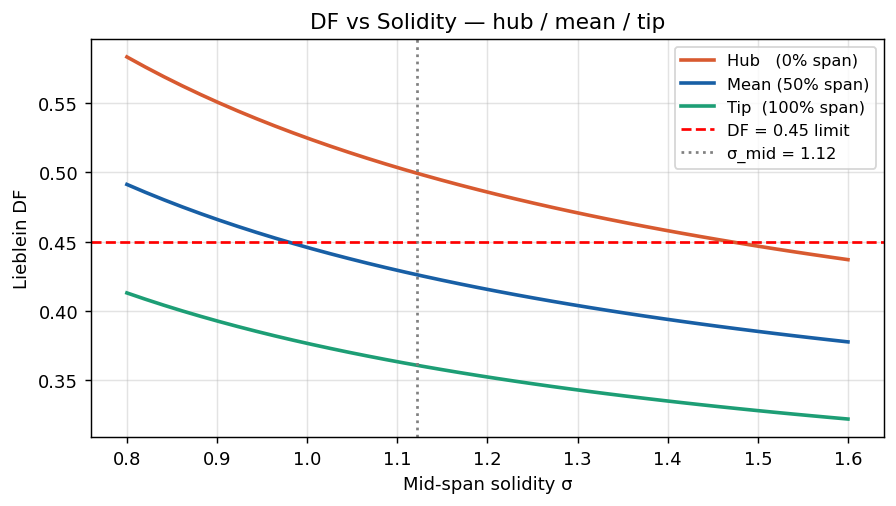

In [18]:
sigma_range = np.linspace(0.8, 1.6, 40)
df_hub   = [free_vortex(res, n_stations=80, sigma=s)['DF'][0]  for s in sigma_range]
df_mean  = [free_vortex(res, n_stations=80, sigma=s)['DF'][40] for s in sigma_range]
df_tip   = [free_vortex(res, n_stations=80, sigma=s)['DF'][-1] for s in sigma_range]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(sigma_range, df_hub,  '#D85A30', lw=2, label='Hub   (0% span)')
ax.plot(sigma_range, df_mean, '#185FA5', lw=2, label='Mean (50% span)')
ax.plot(sigma_range, df_tip,  '#1D9E75', lw=2, label='Tip  (100% span)')
ax.axhline(0.45, color='red', ls='--', lw=1.5, label='DF = 0.45 limit')
ax.axvline(sigma_mid, color='gray', ls=':', lw=1.5, label=f'σ_mid = {sigma_mid:.2f}')
ax.set(xlabel='Mid-span solidity σ', ylabel='Lieblein DF',
       title='DF vs Solidity — hub / mean / tip')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.35)
plt.tight_layout()
plt.savefig('../figures/02_df_vs_sigma.png', dpi=130, bbox_inches='tight')
plt.show()

---
**Proceed to** `03_igv_design.ipynb`.